In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)


In [91]:
tips_df = sns.load_dataset('tips')

In [92]:
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [93]:
tips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [94]:
tips_df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Text(0.5, 1.0, 'Distribution of tips amount')

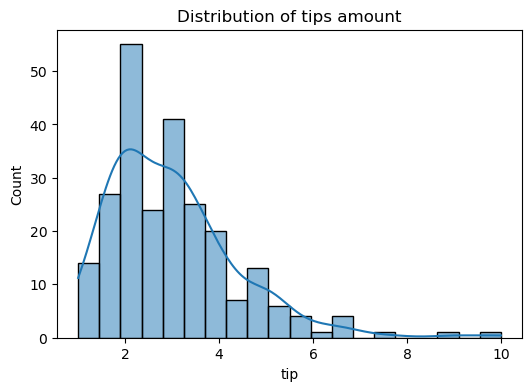

In [95]:
# Distribution of tips amount
plt.figure(figsize=(6, 4))
sns.histplot(tips_df['tip'], kde=True, bins=20)
plt.title('Distribution of tips amount')

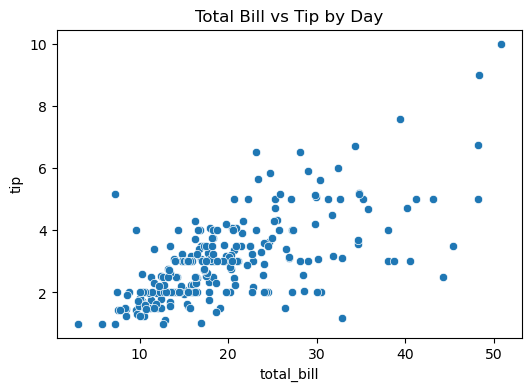

In [96]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='total_bill', y='tip', data=tips_df)
plt.title('Total Bill vs Tip by Day')
plt.show()

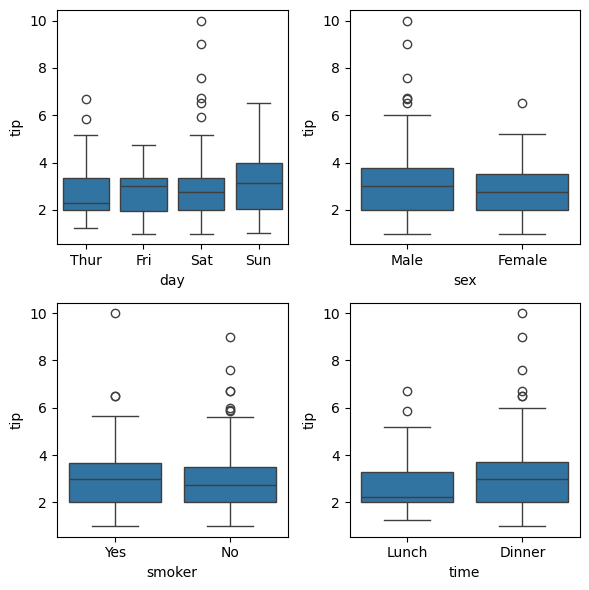

In [97]:
# Box Plots for Categorical Data
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.boxplot(x="day", y="tip", data=tips_df, ax=axes[0, 0])
sns.boxplot(x="sex", y="tip", data=tips_df, ax=axes[0, 1])
sns.boxplot(x="smoker", y="tip", data=tips_df, ax=axes[1, 0])
sns.boxplot(x="time", y="tip", data=tips_df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

In [98]:
# Categorical encoding for 'sex', 'smoker', and 'time'
tips_df['sex'] = tips_df['sex'].cat.codes
tips_df['smoker'] = tips_df['smoker'].cat.codes
tips_df['time'] = tips_df['time'].cat.codes

# One-hot encoding for 'day'
tips_df = pd.get_dummies(tips_df, columns=['day'])

tips_df.head()

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,1,2,False,False,False,True
1,10.34,1.66,0,1,1,3,False,False,False,True
2,21.01,3.50,0,1,1,3,False,False,False,True
3,23.68,3.31,0,1,1,2,False,False,False,True
4,24.59,3.61,1,1,1,4,False,False,False,True


In [99]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()


In [100]:
numerical_features = ['total_bill', 'size']
# tips_df[numerical_features] = scaler.fit_transform(tips_df[numerical_features])

In [101]:
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,1,2,False,False,False,True
1,10.34,1.66,0,1,1,3,False,False,False,True
2,21.01,3.50,0,1,1,3,False,False,False,True
3,23.68,3.31,0,1,1,2,False,False,False,True
4,24.59,3.61,1,1,1,4,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False
240,27.18,2.00,1,0,1,2,False,False,True,False
241,22.67,2.00,0,0,1,2,False,False,True,False
242,17.82,1.75,0,1,1,2,False,False,True,False


In [102]:
X = tips_df.drop(columns=['tip'])
y = tips_df['tip']


In [103]:
X.columns

Index(['total_bill', 'sex', 'smoker', 'time', 'size', 'day_Thur', 'day_Fri',
       'day_Sat', 'day_Sun'],
      dtype='object')

In [104]:
y.name

'tip'

In [105]:
# Calculate correlation
corr_matrix = tips_df.corr()
corr_matrix

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
total_bill,1.000000,0.675734,-0.144877,-0.085721,0.183118,0.598315,-0.138174,-0.086168,0.054919,0.122953
tip,0.675734,1.000000,-0.088862,-0.005929,0.121629,0.489299,-0.095879,-0.055463,-0.002790,0.125114
sex,-0.144877,-0.088862,1.000000,0.002816,-0.205231,-0.086195,0.194445,0.071060,-0.053957,-0.168106
smoker,-0.085721,-0.005929,0.002816,1.000000,-0.054921,0.133178,0.128534,-0.244316,-0.155744,0.181624
time,0.183118,0.121629,-0.205231,-0.054921,1.000000,0.103411,-0.917996,-0.058159,0.462709,0.418071
size,0.598315,0.489299,-0.086195,0.133178,0.103411,1.000000,-0.072598,-0.142184,-0.041121,0.193054
day_Thur,-0.138174,-0.095879,0.194445,0.128534,-0.917996,-0.072598,1.000000,-0.169608,-0.434480,-0.392566
day_Fri,-0.086168,-0.055463,0.071060,-0.244316,-0.058159,-0.142184,-0.169608,1.000000,-0.216319,-0.195451
day_Sat,0.054919,-0.002790,-0.053957,-0.155744,0.462709,-0.041121,-0.434480,-0.216319,1.000000,-0.500682
day_Sun,0.122953,0.125114,-0.168106,0.181624,0.418071,0.193054,-0.392566,-0.195451,-0.500682,1.000000


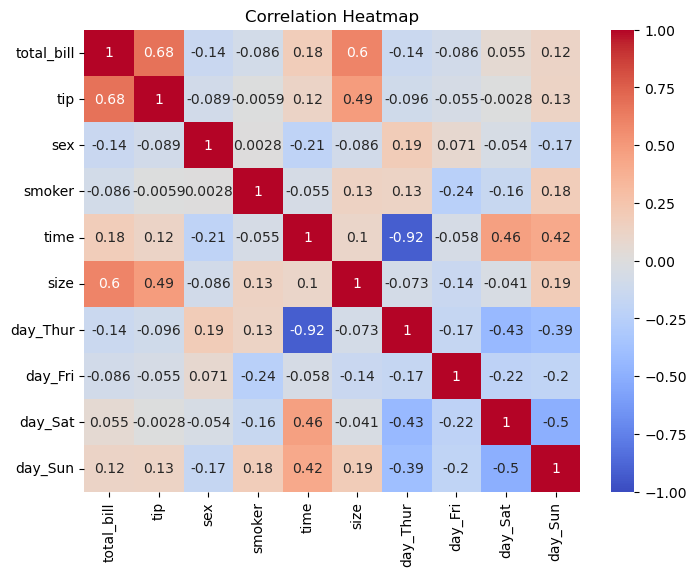

In [106]:
# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

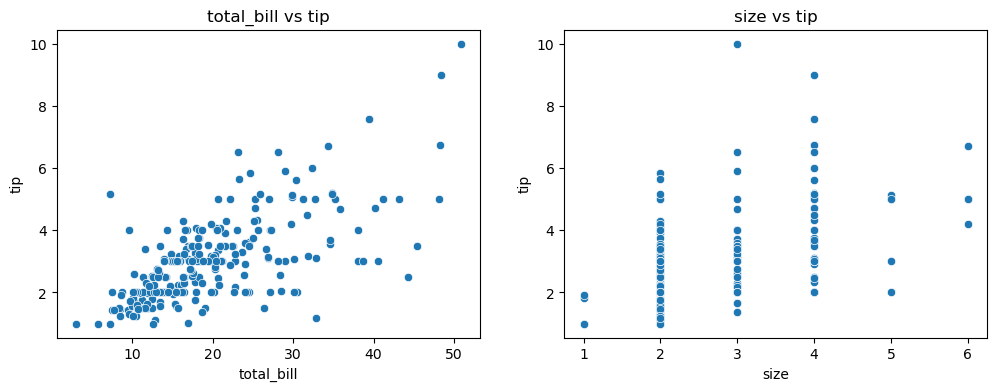

In [107]:
numerical_features = ['total_bill', 'size']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, feature in enumerate(numerical_features):
    sns.scatterplot(x=feature, y='tip', data=tips_df, ax=axes[i])
    axes[i].set_title(f'{feature} vs tip')

In [108]:
Selected_features = ['total_bill', 'size', 'time', 'day_Sat', 'day_Sun']
X_selected = tips_df[Selected_features]

print('Selected features: ', X_selected.columns)

Selected features:  Index(['total_bill', 'size', 'time', 'day_Sat', 'day_Sun'], dtype='object')


## Feature Engineering

Now, let's create some new features from the existing features that might be useful for predicting tip amount.

In [109]:
tips_df['tip_percentage'] = tips_df['tip'] / tips_df['total_bill'] * 100
                                    
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426


In [110]:
tips_df['per_person_total'] = tips_df["total_bill"] / tips_df['size']
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500
...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000


In [111]:
tips_df['is_weekend'] = tips_df['day_Sat'] | tips_df['day_Sun']
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True


In [112]:
tips_df['party_size_category'] = pd.cut(tips_df['size'], bins=[0, 3, 6, np.inf], labels=['Small', 'Medium', 'Large'])
tips_df = pd.get_dummies(tips_df, columns=['party_size_category'], prefix='party')

In [113]:
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True,True,False,False
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True,True,False,False
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True,True,False,False
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True,True,False,False
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True,True,False,False
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True,True,False,False
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True,True,False,False
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True,True,False,False


In [114]:
np.abs(tips_df.corr())['tip'].sort_values(ascending=False)

tip                 1.000000
total_bill          0.675734
size                0.489299
party_Small         0.425938
party_Medium        0.425938
per_person_total    0.347393
tip_percentage      0.342370
day_Sun             0.125114
time                0.121629
is_weekend          0.120198
day_Thur            0.095879
sex                 0.088862
day_Fri             0.055463
smoker              0.005929
day_Sat             0.002790
party_Large              NaN
Name: tip, dtype: float64

In [115]:
selected_features = ['total_bill', 'size','party_Small','party_Medium','per_person_total', 'tip_percentage', 'day_Sun', 'time', 'is_weekend', 'day_Thur', 'sex', 'day_Fri', 'smoker', 'day_Sat', 'party_Large']
X_selected = tips_df[selected_features]

print("updated selected features", X_selected.columns)

updated selected features Index(['total_bill', 'size', 'party_Small', 'party_Medium', 'per_person_total',
       'tip_percentage', 'day_Sun', 'time', 'is_weekend', 'day_Thur', 'sex',
       'day_Fri', 'smoker', 'day_Sat', 'party_Large'],
      dtype='object')


In [116]:
from sklearn.model_selection import train_test_split

X = X_selected.astype(np.float64)
y = tips_df['tip'].astype(np.float64)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.2,
                                                     random_state=42)


In [117]:
assert X_train.shape[0] + X_test.shape[0] == tips_df.shape[0], "Training and testing sets are not of equal size"
assert X_train.shape[1] == X_test.shape[1], "Training and testing sets are not of equal size"

### Implementing Multiple Linear Regression

In [118]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Initialize the model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Examining the Model 

In [119]:
lr_model.coef_

array([ 0.12658234,  0.16324035, -0.02888445,  0.02888445,  0.03041153,
        0.14921359, -0.12141582, -0.04227221, -0.05299908, -0.00244193,
       -0.03469284,  0.05544101,  0.34252591,  0.06841673,  0.        ])

In [120]:
# print the intercept and coefficients
print("Intercept: ", lr_model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef}")

Intercept:  -2.6505620199484357

Coefficients:
total_bill: 0.12658233852666087
size: 0.16324034778114932
party_Small: -0.02888445244406671
party_Medium: 0.02888445244406689
per_person_total: 0.030411529677353166
tip_percentage: 0.14921358905444265
day_Sun: -0.12141581723643977
time: -0.04227220551763353
is_weekend: -0.05299908295648053
day_Thur: -0.002441928312161882
sex: -0.0346928388950637
day_Fri: 0.05544101126864247
smoker: 0.3425259111259791
day_Sat: 0.0684167342799593
party_Large: 0.0


In [124]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Training set performance
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Test set performance
    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    print("Training Set Results:")
    print("Mean Squared Error: ", mse_train)
    print(f"Root Mean Squared Error: {np.sqrt(mse_train)}")
    print("R2 Score: ", r2_train)
    print()

    print("Test Set Results:")
    print("Mean Squared Error: ", mse_test)
    print(f"Root Mean Squared Error: {np.sqrt(mse_test)}")
    print("R2 Score: ", r2_test)
    

    return mse_train,rmse_train, r2_train, mse_test,rmse_test, r2_test

# Evaluate the model
evaluate_model(lr_model, X_train, y_train, X_test, y_test)

Training Set Results:
Mean Squared Error:  0.32871497308515507
Root Mean Squared Error: 0.5733367013240606
R2 Score:  0.8382075264440115

Test Set Results:
Mean Squared Error:  0.2318525110223616
Root Mean Squared Error: 0.48151065514935554
R2 Score:  0.8145137391355477


(0.32871497308515507,
 np.float64(0.5733367013240606),
 0.8382075264440115,
 0.2318525110223616,
 np.float64(0.48151065514935554),
 0.8145137391355477)

### Visualizing Predicitons

Let's create a scatter plot of the predictions and the actual values.

Text(0.5, 1.0, 'Actual vs Predicted Tips (Test Set)')

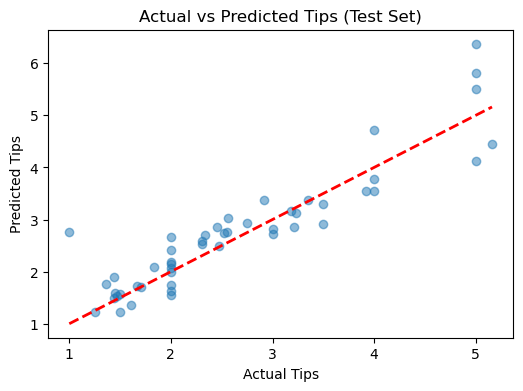

In [125]:
y_test_pred = lr_model.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--',lw=2 )
plt.xlabel('Actual Tips')
plt.ylabel('Predicted Tips')
plt.title('Actual vs Predicted Tips (Test Set)')


### Residual Analysis

Finally, let's perform a residual analysis to check for any pattern in our errors.

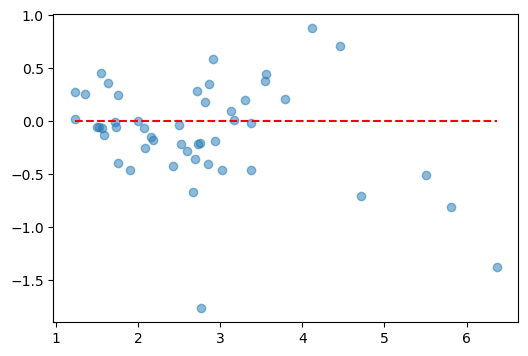

In [128]:
residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), color='r', linestyles='dashed')

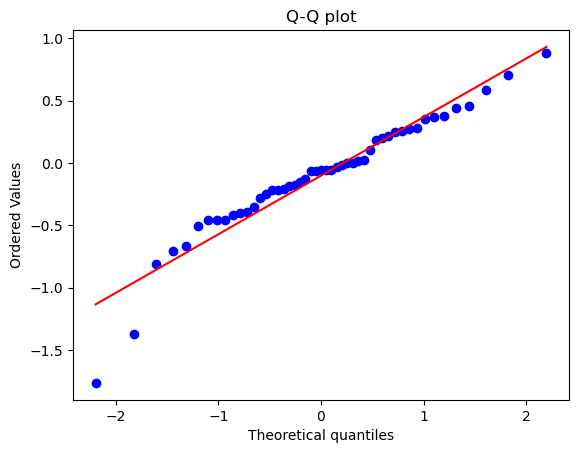

In [132]:
import scipy.stats as stats

fig, ax = plt.subplots()
stats.probplot((y_test - y_test_pred), plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

## Regulariztion techniques

### 1. L2 regularization

$$

In [133]:
## Implementing a Ridge Regression Model

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score


In [134]:
# Initialize Ridge model
ridge_model = Ridge(alpha=1.0) # alpha is the regularization strength


In [135]:
# Fit the model 
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [136]:
# Evaluate the model 
print("Ridge Regression Results:")
evaluate_model(ridge_model, X_train, y_train, X_test, y_test)

Ridge Regression Results:
Training Set Results:
Mean Squared Error:  0.32874551162790705
Root Mean Squared Error: 0.5733633329991612
R2 Score:  0.8381924954695346

Test Set Results:
Mean Squared Error:  0.23179662775629922
Root Mean Squared Error: 0.4814526225458734
R2 Score:  0.8145584467732657


(0.32874551162790705,
 np.float64(0.5733633329991612),
 0.8381924954695346,
 0.23179662775629922,
 np.float64(0.4814526225458734),
 0.8145584467732657)

In [137]:
ridge_model.coef_

array([ 0.12783922,  0.15273487, -0.02961114,  0.02961114,  0.02686332,
        0.14905292, -0.11822543, -0.0367491 , -0.05298048,  0.00326322,
       -0.03356211,  0.04971726,  0.33247112,  0.06524495,  0.        ])

In [138]:
lr_model.coef_

array([ 0.12658234,  0.16324035, -0.02888445,  0.02888445,  0.03041153,
        0.14921359, -0.12141582, -0.04227221, -0.05299908, -0.00244193,
       -0.03469284,  0.05544101,  0.34252591,  0.06841673,  0.        ])

In [139]:
from sklearn.linear_model import Lasso

# Initialize Lasso model
lasso_model = Lasso(alpha=0.1) # alpha is the regularization strength

# Fit the model
lasso_model.fit(X_train, y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [140]:
# Evaluate the model
print("Lasso Regression Results:")
evaluate_model(lasso_model, X_train, y_train, X_test, y_test)

Lasso Regression Results:
Training Set Results:
Mean Squared Error:  0.3625789978676584
Root Mean Squared Error: 0.6021453295240763
R2 Score:  0.821539760194425

Test Set Results:
Mean Squared Error:  0.20794003570724381
Root Mean Squared Error: 0.456004425096121
R2 Score:  0.8336441579291872


(0.3625789978676584,
 np.float64(0.6021453295240763),
 0.821539760194425,
 0.20794003570724381,
 np.float64(0.456004425096121),
 0.8336441579291872)

In [141]:
lasso_model.coef_


array([ 0.14231373,  0.        , -0.        ,  0.        , -0.01790016,
        0.1428313 , -0.        , -0.        , -0.        ,  0.        ,
       -0.        , -0.        ,  0.        ,  0.        ,  0.        ])

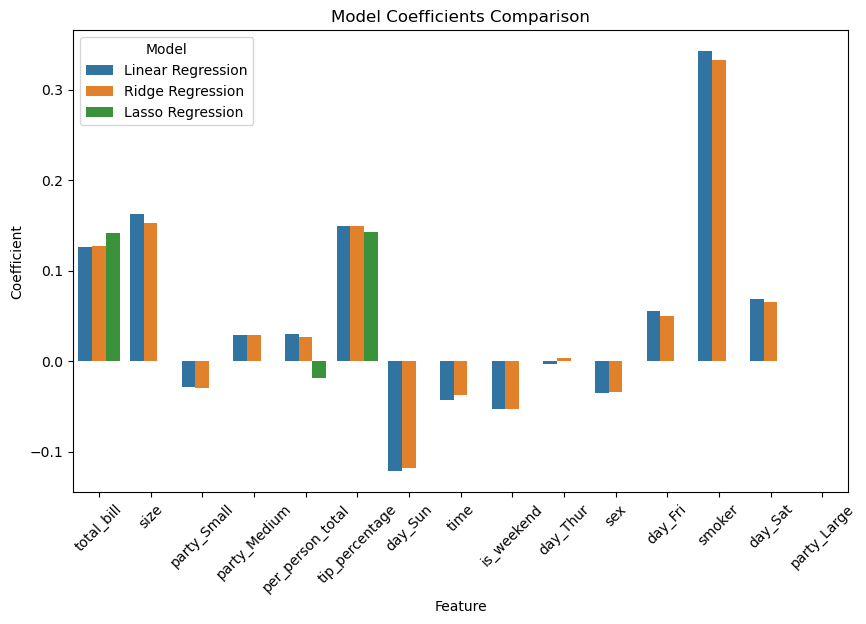

In [144]:
# Visualizing Coefficients from Different Models
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Linear Regression': lr_model.coef_,
    'Ridge Regression': ridge_model.coef_,
    'Lasso Regression': lasso_model.coef_
})
coefficients_melted = coefficients.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=coefficients_melted)
plt.title('Model Coefficients Comparison')
plt.xticks(rotation=45);

